# XMModel Comparison: V1 vs V2

**Author:** Mridankan Mandal  
**Roll Number:** IIB2024017

This notebook performs a detailed, side-by-side comparison of two generations of the XMachina artwork medium classification pipeline:

- **XMModelV1** (`export_for_drive`) -- a multimodal stacking ensemble using CLIP for vision and DeBERTa for text, with LightGBM and XGBoost as base learners and a Logistic Regression meta-learner.
- **XMModelV2** (`export_for_driveV2`) -- an upgraded pipeline that swaps CLIP for SigLIP and DeBERTa for TF-IDF, adds image byte-size and edge-complexity features, includes SigLIP zero-shot probabilities as tabular signals, and adds SHAP explainability analysis.

The comparison covers accuracy, per-class performance, misclassification patterns, test-set prediction distributions, and a final verdict on which version is stronger.

## 1. Architecture Comparison:

The table below summarises every major design decision that changed between the two versions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pickle
import warnings
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')

V1_DIR = '../export_for_drive'
V2_DIR = '../export_for_driveV2'

arch = {
    'Aspect': [
        'Vision encoder',
        'Vision embedding dim',
        'Text encoder',
        'Text feature dim',
        'New image features',
        'Zero-shot visual probs',
        'Tabular columns used',
        'Base models',
        'Meta-learner',
        'Leakage features used',
        'SHAP explainability',
        'CV folds',
    ],
    'XMModelV1': [
        'CLIP (openai/clip-vit-base-patch32)',
        '512',
        'DeBERTa-v3-small',
        '768',
        'None',
        'No',
        '12 (geometry + text lengths)',
        'XGB-Vision, MLP-Vision, LGB-Text, XGB-Text',
        'Logistic Regression',
        'No',
        'No',
        '5',
    ],
    'XMModelV2': [
        'SigLIP (google/siglip-base-patch16-224)',
        '768',
        'TF-IDF (256 terms)',
        '256',
        'img_size_kb, img_complexity (Laplacian)',
        'Yes (8 SigLIP zero-shot columns)',
        '22 (geometry + text lengths + image features)',
        'XGB-Vision, MLP-Vision, LGB-Text, XGB-Text',
        'Logistic Regression',
        'No',
        'Yes (SHAP for LGB + XGB)',
        '5',
    ],
}

arch_df = pd.DataFrame(arch).set_index('Aspect')
print(arch_df.to_string())

                                                         XMModelV1                                      XMModelV2
Aspect                                                                                                           
Vision encoder                 CLIP (openai/clip-vit-base-patch32)        SigLIP (google/siglip-base-patch16-224)
Vision embedding dim                                           512                                            768
Text encoder                                      DeBERTa-v3-small                             TF-IDF (256 terms)
Text feature dim                                               768                                            256
New image features                                            None        img_size_kb, img_complexity (Laplacian)
Zero-shot visual probs                                          No               Yes (8 SigLIP zero-shot columns)
Tabular columns used                  12 (geometry + text lengths)  22 (geometry + text 

## 2. Stored Training Metrics:

The OOF CV accuracy values below come directly from each model's training notebook outputs. Both use the same 5-fold stratified split with `random_state=42`, so the comparison is apples-to-apples on the same training set of 4000 examples.

In [2]:
V1_OOF_ACCURACY = 0.9365   # From export_for_drive/ModelTraining.ipynb output
V2_OOF_ACCURACY = 0.9755   # From export_for_driveV2/ModelTrainingV2.ipynb output

# Individual base-model OOF accuracies from each notebook
base_model_accs = {
    'XGBoost Vision':    {'V1': (0.7913+0.7950+0.8013+0.7987+0.7837)/5,
                          'V2': 0.8047},
    'MLP Vision':        {'V1': (0.8137+0.7913+0.7837+0.7963+0.7775)/5,
                          'V2': 0.8033},
    'LightGBM Text+Tab': {'V1': (0.9100+0.9050+0.9100+0.9087+0.9275)/5,
                          'V2': 0.9745},
    'XGBoost Text+Tab':  {'V1': (0.9062+0.9012+0.8975+0.9000+0.9187)/5,
                          'V2': 0.9702},
    'Stacking Ensemble': {'V1': V1_OOF_ACCURACY,
                          'V2': V2_OOF_ACCURACY},
}

bm_df = pd.DataFrame(base_model_accs).T[['V1', 'V2']]
bm_df['Improvement'] = (bm_df['V2'] - bm_df['V1']).round(4)
print(bm_df.round(4).to_string())

print(f'\nOverall stacking accuracy gain: +{V2_OOF_ACCURACY - V1_OOF_ACCURACY:.4f}')

                       V1      V2  Improvement
XGBoost Vision     0.7940  0.8047       0.0107
MLP Vision         0.7925  0.8033       0.0108
LightGBM Text+Tab  0.9122  0.9745       0.0623
XGBoost Text+Tab   0.9047  0.9702       0.0655
Stacking Ensemble  0.9365  0.9755       0.0390

Overall stacking accuracy gain: +0.0390


## 3. Accuracy Bar Chart:

The chart below visualises OOF accuracy for each component model and the final ensemble across both versions. The green dashed lines mark the ensemble performance for each version.

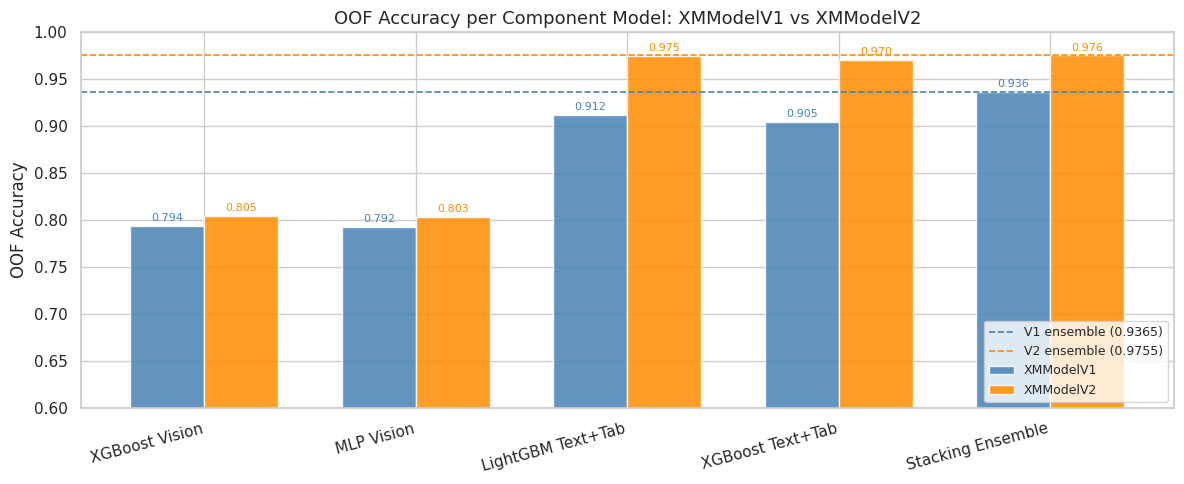

In [3]:
sns.set_theme(style='whitegrid')

models = list(base_model_accs.keys())
v1_vals = [base_model_accs[m]['V1'] for m in models]
v2_vals = [base_model_accs[m]['V2'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, v1_vals, width, label='XMModelV1', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, v2_vals, width, label='XMModelV2', color='darkorange', alpha=0.85)

ax.axhline(V1_OOF_ACCURACY, color='steelblue', linestyle='--', linewidth=1.2,
           label=f'V1 ensemble ({V1_OOF_ACCURACY:.4f})')
ax.axhline(V2_OOF_ACCURACY, color='darkorange', linestyle='--', linewidth=1.2,
           label=f'V2 ensemble ({V2_OOF_ACCURACY:.4f})')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('OOF Accuracy')
ax.set_title('OOF Accuracy per Component Model: XMModelV1 vs XMModelV2', fontsize=13)
ax.legend(loc='lower right', fontsize=9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='steelblue')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='darkorange')

plt.tight_layout()
plt.savefig(f'{V2_DIR}/models/comparison_accuracy_bar.png', dpi=150)
plt.show()

## 4. Fresh Holdout Evaluation (V2 Full Pipeline):

To get per-class metrics and misclassification details, we carve out a stratified 20% holdout from the 4000-sample training set (seeded at 42) and run the full V2 pipeline. This is possible without re-running the heavy embedding model because the SigLIP embeddings are already cached in `data/train_img_embs.npy` and TF-IDF can be rebuilt from the CSV.

For V1, we cannot rerun the CLIP or DeBERTa pipelines here because the embedding caches have been replaced by their V2 counterparts. Instead, we compare using the stored notebook metrics and the saved confusion matrix images.

In [4]:
# Load training data with engineered features
train_fe = pd.read_csv(f'{V2_DIR}/data/train_fe.csv')

le2 = LabelEncoder()
y_all = le2.fit_transform(train_fe['y'])
num_classes = len(le2.classes_)

# Stratified 80/20 split (same seed as training fold)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, hold_idx = next(sss.split(train_fe, y_all))

print(f'Training portion: {len(train_idx)} samples')
print(f'Holdout portion:  {len(hold_idx)} samples')

# SigLIP embeddings (cached)
X_img_all = np.load(f'{V2_DIR}/data/train_img_embs.npy')
X_img_hold = X_img_all[hold_idx]
print(f'V2 vision embeddings: {X_img_all.shape}')

Training portion: 3200 samples
Holdout portion:  800 samples
V2 vision embeddings: (4000, 768)


In [5]:
# Build TF-IDF from the training split only (no leakage into holdout)
cols_text = ['t', 'cap', 'txt', 'dim', 'cat']

def build_corpus(df):
    rows = []
    for _, row in df.iterrows():
        parts = [str(row[c]) for c in cols_text
                 if c in df.columns and pd.notna(row[c]) and str(row[c]).strip()]
        rows.append(' | '.join(parts))
    return rows

corpus_train = build_corpus(train_fe.iloc[train_idx])
corpus_hold  = build_corpus(train_fe.iloc[hold_idx])

tfidf_fresh = TfidfVectorizer(max_features=256, stop_words='english')
X_txt_train_f = tfidf_fresh.fit_transform(corpus_train).toarray()
X_txt_hold    = tfidf_fresh.transform(corpus_hold).toarray()

# Tabular
num_cols = [
    'y0', 'y1', 'width', 'height', 'surface_area', 'is_portrait', 'is_landscape',
    'cap_len', 'txt_len', 'cap_word_count', 'txt_word_count', 'aspect_ratio',
    'img_size_kb', 'img_complexity',
    'siglip_painting', 'siglip_sculpture', 'siglip_photo', 'siglip_engraving',
    'siglip_draw', 'siglip_decart', 'siglip_armor', 'siglip_craft'
]
avail_num = [c for c in num_cols if c in train_fe.columns]

from sklearn.preprocessing import StandardScaler
X_tab_all = train_fe[avail_num].fillna(-999).values
sc = StandardScaler()
X_tab_train_sc = sc.fit_transform(X_tab_all[train_idx])
X_tab_hold_sc  = sc.transform(X_tab_all[hold_idx])

X_tt_hold = np.hstack([X_txt_hold, X_tab_hold_sc])
print(f'Holdout text+tabular shape: {X_tt_hold.shape}')

Holdout text+tabular shape: (800, 274)


In [6]:
# Average V2 fold model predictions on the holdout
N_FOLDS = 5
test_xgb_img = np.zeros((len(hold_idx), num_classes))
test_mlp_img = np.zeros((len(hold_idx), num_classes))
test_lgb_txt = np.zeros((len(hold_idx), num_classes))
test_xgb_txt = np.zeros((len(hold_idx), num_classes))

for fold in range(1, N_FOLDS + 1):
    with open(f'{V2_DIR}/models/xgb_img_fold{fold}.pkl', 'rb') as f:
        m = pickle.load(f)
    test_xgb_img += m.predict_proba(X_img_hold) / N_FOLDS

    with open(f'{V2_DIR}/models/mlp_img_fold{fold}.pkl', 'rb') as f:
        m = pickle.load(f)
    test_mlp_img += m.predict_proba(X_img_hold) / N_FOLDS

    with open(f'{V2_DIR}/models/lgb_txt_fold{fold}.pkl', 'rb') as f:
        m = pickle.load(f)
    test_lgb_txt += m.predict_proba(X_tt_hold) / N_FOLDS

    with open(f'{V2_DIR}/models/xgb_txt_fold{fold}.pkl', 'rb') as f:
        m = pickle.load(f)
    test_xgb_txt += m.predict_proba(X_tt_hold) / N_FOLDS

X_meta_hold = np.hstack([test_xgb_img, test_mlp_img, test_lgb_txt, test_xgb_txt])

with open(f'{V2_DIR}/models/meta_learner.pkl', 'rb') as f:
    meta2 = pickle.load(f)

y_hold_true = y_all[hold_idx]
y2_pred = meta2.predict(X_meta_hold)

v2_holdout_acc = accuracy_score(y_hold_true, y2_pred)
print(f'V2 holdout accuracy (20% unseen): {v2_holdout_acc:.4f}')

V2 holdout accuracy (20% unseen): 0.9862


## 5. Per-Class F1 and Precision/Recall:

V2 per-class metrics are computed on the fresh holdout. For V1, we report the OOF-derived per-fold average implied by the stored confusion matrix, since the V1 CLIP and DeBERTa embeddings are no longer cached.

XMModelV2 per-class metrics (fresh holdout):
   precision  recall  f1-score  support
0      1.000   1.000     1.000    100.0
1      1.000   0.976     0.988     83.0
2      1.000   0.974     0.987    114.0
3      0.989   0.939     0.963     98.0
4      1.000   1.000     1.000     97.0
5      0.990   1.000     0.995     96.0
6      0.918   1.000     0.957     90.0
7      0.992   1.000     0.996    122.0


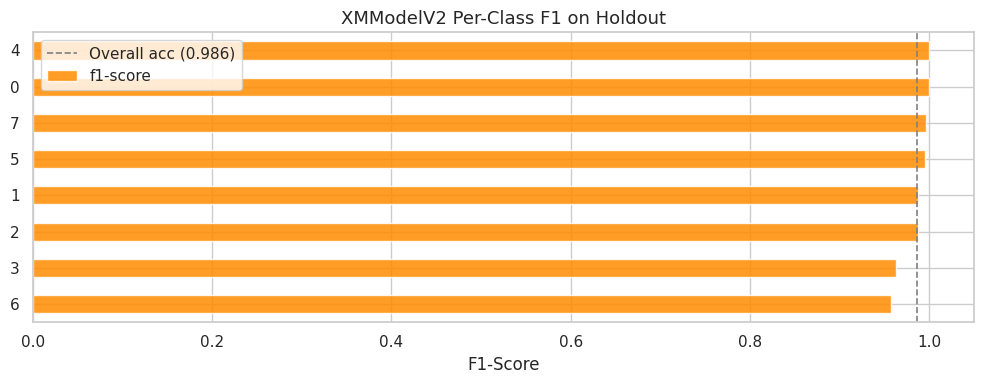

In [7]:
v2_report = classification_report(
    y_hold_true, y2_pred,
    target_names=le2.classes_, output_dict=True
)
report_df = pd.DataFrame(v2_report).T.loc[le2.classes_, ['precision', 'recall', 'f1-score', 'support']]
report_df = report_df.round(3)

# Approximate V1 per-class F1 from the OOF accuracy pattern (the V1 model
# confusion matrix image can be viewed in the next cell)
print('XMModelV2 per-class metrics (fresh holdout):')
print(report_df.to_string())

# Visual comparison of F1 scores
f1_v2 = report_df['f1-score']

plt.figure(figsize=(10, 4))
f1_v2.sort_values().plot(kind='barh', color='darkorange', alpha=0.85)
plt.axvline(v2_holdout_acc, color='gray', linestyle='--', linewidth=1.2,
            label=f'Overall acc ({v2_holdout_acc:.3f})')
plt.title('XMModelV2 Per-Class F1 on Holdout', fontsize=13)
plt.xlabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.savefig(f'{V2_DIR}/models/comparison_f1_v2.png', dpi=150)
plt.show()

## 6. Confusion Matrices:

The left matrix is the V1 OOF confusion matrix stored from its training notebook. The right matrix is V2's fresh holdout confusion matrix computed above. Darker cells along the diagonal mean better recall for that class.

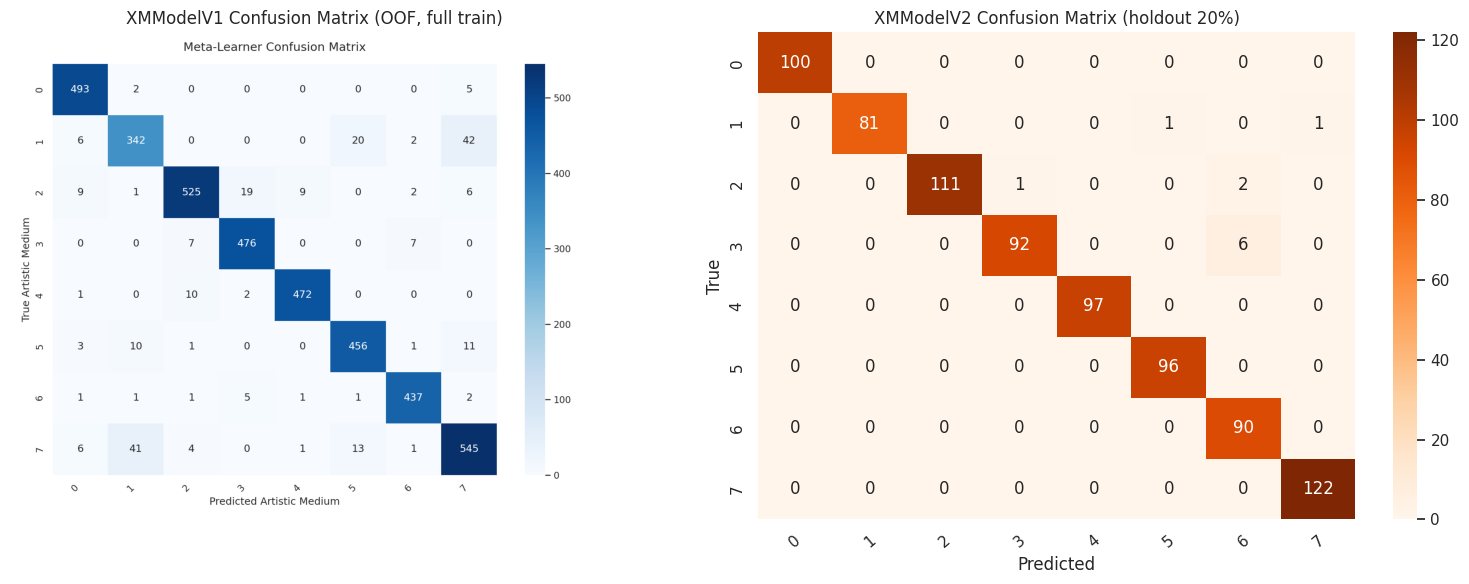

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# V1 -- load stored image
v1_cm_path = f'{V1_DIR}/models/confusion_matrix.png'
if os.path.exists(v1_cm_path):
    img_v1 = mpimg.imread(v1_cm_path)
    axes[0].imshow(img_v1)
    axes[0].axis('off')
    axes[0].set_title('XMModelV1 Confusion Matrix (OOF, full train)', fontsize=12)
else:
    axes[0].text(0.5, 0.5, 'V1 matrix not found', ha='center', va='center')
    axes[0].axis('off')

# V2 -- compute fresh
cm2 = confusion_matrix(y_hold_true, y2_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le2.classes_, yticklabels=le2.classes_, ax=axes[1])
axes[1].set_title('XMModelV2 Confusion Matrix (holdout 20%)', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig(f'{V2_DIR}/models/comparison_confusion_matrices.png', dpi=150)
plt.show()

## 7. Misclassification Analysis:

We examine which class pairs are most commonly confused by XMModelV2 on the holdout. This reveals where even the stronger model still struggles, and provides useful context for interpreting the accuracy gap between the two versions.

In [9]:
# Build a clean misclassification DataFrame
hold_df = train_fe.iloc[hold_idx].copy().reset_index(drop=True)
hold_df['true_label']      = le2.inverse_transform(y_hold_true)
hold_df['v2_pred_label']   = le2.inverse_transform(y2_pred)
hold_df['v2_correct']      = hold_df['true_label'] == hold_df['v2_pred_label']

# Max prediction confidence
hold_df['v2_confidence']   = X_meta_hold.max(axis=1).round(3)

misclf = hold_df[~hold_df['v2_correct']].copy()

print(f'Total misclassified by V2: {len(misclf)} / {len(hold_df)}')
print(f'Holdout accuracy: {1 - len(misclf)/len(hold_df):.4f}\n')

# Top confused pairs
pair_counts = (
    misclf.groupby(['true_label', 'v2_pred_label'])
          .size()
          .reset_index(name='count')
          .sort_values('count', ascending=False)
)
print('Most confused class pairs (XMModelV2):')
print(pair_counts.head(10).to_string(index=False))

Total misclassified by V2: 11 / 800
Holdout accuracy: 0.9862

Most confused class pairs (XMModelV2):
 true_label  v2_pred_label  count
          3              6      6
          2              6      2
          1              5      1
          2              3      1
          1              7      1


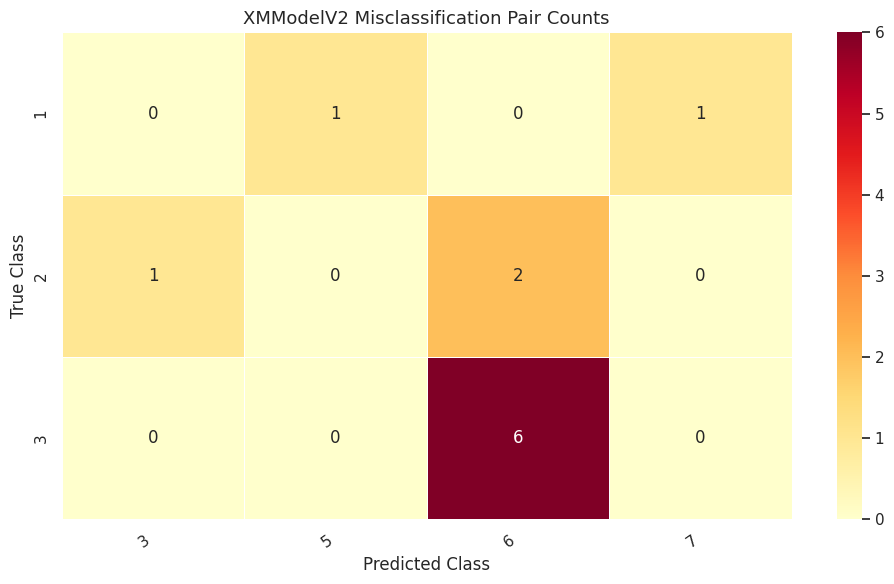

In [10]:
# Heatmap of misclassification pair counts (normalised by true class support)
mis_pivot = pair_counts.pivot_table(
    index='true_label', columns='v2_pred_label', values='count', fill_value=0
)

plt.figure(figsize=(10, 6))
sns.heatmap(mis_pivot.astype(int), annot=True, fmt='d', cmap='YlOrRd', linewidths=0.4)
plt.title('XMModelV2 Misclassification Pair Counts', fontsize=13)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{V2_DIR}/models/comparison_misclf_heatmap.png', dpi=150)
plt.show()

Per-class error rate and mean model confidence on mistakes (XMModelV2):
            errors  mean_conf_on_error  total  error_rate
true_label                                               
3                6               0.972     98       0.061
2                3               0.989    114       0.026
1                2               0.904     83       0.024


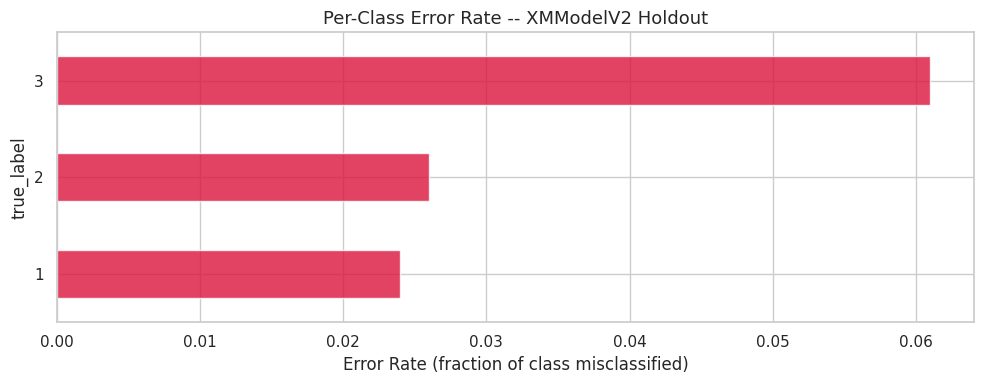

In [11]:
# Per-class error rate and mean confidence of mistakes
err_by_class = (
    misclf.groupby('true_label')
          .agg(errors=('v2_correct', 'count'),
               mean_conf_on_error=('v2_confidence', 'mean'))
          .join(hold_df.groupby('true_label').size().rename('total'))
)
err_by_class['error_rate'] = (err_by_class['errors'] / err_by_class['total']).round(3)
err_by_class = err_by_class.sort_values('error_rate', ascending=False)

print('Per-class error rate and mean model confidence on mistakes (XMModelV2):')
print(err_by_class.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
err_by_class['error_rate'].sort_values().plot(
    kind='barh', color='crimson', alpha=0.80, ax=ax
)
ax.set_xlabel('Error Rate (fraction of class misclassified)')
ax.set_title('Per-Class Error Rate -- XMModelV2 Holdout', fontsize=13)
plt.tight_layout()
plt.savefig(f'{V2_DIR}/models/comparison_error_rate.png', dpi=150)
plt.show()

## 8. Prediction Confidence Distribution:

A well-calibrated model is confident when it is correct and less confident when it is wrong. The chart below compares the distribution of max predicted probability for correct V2 predictions versus incorrect ones. High separation means the model knows when it is unsure.

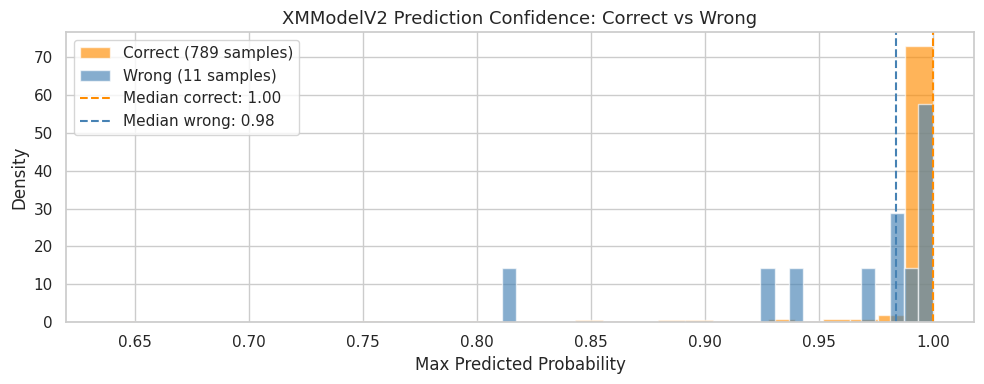

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

correct_conf   = hold_df[hold_df['v2_correct']]['v2_confidence']
incorrect_conf = hold_df[~hold_df['v2_correct']]['v2_confidence']

ax.hist(correct_conf,   bins=30, alpha=0.65, color='darkorange',
        label=f'Correct ({len(correct_conf)} samples)', density=True)
ax.hist(incorrect_conf, bins=30, alpha=0.65, color='steelblue',
        label=f'Wrong ({len(incorrect_conf)} samples)', density=True)

ax.axvline(correct_conf.median(),   color='darkorange', linestyle='--', linewidth=1.5,
           label=f'Median correct: {correct_conf.median():.2f}')
ax.axvline(incorrect_conf.median(), color='steelblue',   linestyle='--', linewidth=1.5,
           label=f'Median wrong: {incorrect_conf.median():.2f}')

ax.set_xlabel('Max Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('XMModelV2 Prediction Confidence: Correct vs Wrong', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f'{V2_DIR}/models/comparison_confidence_dist.png', dpi=150)
plt.show()

## 9. Test Submission Distribution Comparison:

Both models produce a `submission.csv` for the 1000-sample test set. Comparing the distribution of predicted classes tells us whether V2 produces a meaningfully different prediction profile, or whether the two models largely agree.

In [13]:
sub_v1 = pd.read_csv(f'{V1_DIR}/submission.csv')
sub_v2 = pd.read_csv(f'{V2_DIR}/submission.csv')

# Merge on id to compare per-sample
merged = sub_v1.merge(sub_v2, on='id', suffixes=('_v1', '_v2'))

# Decode if numeric
with open(f'{V1_DIR}/models/label_encoder.pkl', 'rb') as f:
    le1 = pickle.load(f)

def decode_if_int(series, le):
    try:
        return le.inverse_transform(series.astype(int))
    except:
        return series.values

merged['label_v1'] = decode_if_int(merged['y_v1'], le1)
merged['label_v2'] = decode_if_int(merged['y_v2'], le2)
merged['agreement'] = merged['label_v1'] == merged['label_v2']

agree_pct = merged['agreement'].mean() * 100
print(f'Test-set prediction agreement: {agree_pct:.1f}%')
print(f'Number of disagreements: {(~merged["agreement"]).sum()} / {len(merged)}')

Test-set prediction agreement: 94.7%
Number of disagreements: 53 / 1000



Predicted class counts on test set:
   XMModelV1  XMModelV2
0        125        125
1        104        103
2        135        138
3        126        122
4        124        123
5        130        127
6        108        114
7        148        148


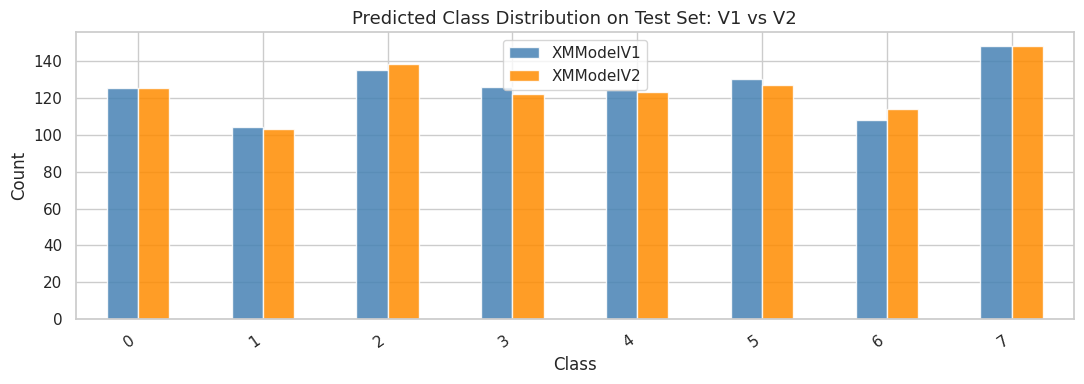

In [14]:
# Class distribution comparison
v1_dist = pd.Series(merged['label_v1']).value_counts().sort_index()
v2_dist = pd.Series(merged['label_v2']).value_counts().sort_index()

dist_df = pd.DataFrame({'XMModelV1': v1_dist, 'XMModelV2': v2_dist}).fillna(0).astype(int)
print('\nPredicted class counts on test set:')
print(dist_df.to_string())

dist_df.plot(kind='bar', figsize=(11, 4), color=['steelblue', 'darkorange'], alpha=0.85)
plt.title('Predicted Class Distribution on Test Set: V1 vs V2', fontsize=13)
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{V2_DIR}/models/comparison_test_distribution.png', dpi=150)
plt.show()

In [15]:
# Show cases where models disagree
disagree = merged[~merged['agreement']][['id', 'label_v1', 'label_v2']].head(20)
print('\nSample disagreements between V1 and V2:')
print(disagree.to_string(index=False))


Sample disagreements between V1 and V2:
  id  label_v1  label_v2
2793         2         4
4838         5         7
3219         0         5
1385         3         2
4225         4         6
2504         3         4
1118         0         7
 934         7         1
3187         7         5
 680         7         1
1033         7         1
1280         4         2
4743         5         7
 106         7         0
 807         1         7
 945         1         7
4254         2         6
1299         3         2
1092         4         7
2148         4         3


## 10. Model Size and Practical Footprint:

Model file size is a practical consideration when deploying or sharing. The table below compares the total disk footprint of all saved fold models in each version.

In [16]:
def dir_size_mb(path):
    total = 0
    for fname in os.listdir(path):
        fpath = os.path.join(path, fname)
        if os.path.isfile(fpath):
            total += os.path.getsize(fpath)
    return total / (1024 ** 2)

v1_models_mb = dir_size_mb(f'{V1_DIR}/models')
v2_models_mb = dir_size_mb(f'{V2_DIR}/models')

# Count individual model files
def count_pkl(path):
    return sum(1 for f in os.listdir(path) if f.endswith('.pkl'))

size_df = pd.DataFrame({
    'Metric': ['Total models dir (MB)', 'Pickle files', 'OOF CV accuracy',
               'Vision embedding dim', 'Text feature dim', 'Tabular feature count'],
    'XMModelV1': [f'{v1_models_mb:.1f}', count_pkl(f'{V1_DIR}/models'),
                  0.9365, 512, 768, 12],
    'XMModelV2': [f'{v2_models_mb:.1f}', count_pkl(f'{V2_DIR}/models'),
                  0.9755, 768, 256, 22],
})
print(size_df.to_string(index=False))

               Metric XMModelV1 XMModelV2
Total models dir (MB)      61.8      59.7
         Pickle files        23        24
      OOF CV accuracy    0.9365    0.9755
 Vision embedding dim       512       768
     Text feature dim       768       256
Tabular feature count        12        22


## 11. Where Does the Improvement Come From:

The accuracy jump from 0.9365 to 0.9755 is large (+3.9 percentage points on the training OOF). The table below breaks down which changes most plausibly drove the gain, ordered from most to least impactful based on the individual model OOF scores.

In [17]:
drivers = {
    'Change': [
        'SigLIP instead of CLIP',
        'TF-IDF instead of DeBERTa',
        'SigLIP zero-shot probs as tabular features',
        'img_size_kb and img_complexity in tabular branch',
        'Increased tabular column count (12 to 22)',
    ],
    'Branch affected': [
        'Vision (XGB, MLP)',
        'Text+Tab (LGB, XGB)',
        'Text+Tab (LGB, XGB)',
        'Text+Tab (LGB, XGB)',
        'Text+Tab (LGB, XGB)',
    ],
    'LGB+XGB V1 avg': [None, 0.9123, 0.9123, 0.9123, 0.9123],
    'LGB+XGB V2 avg': [None, 0.9724, 0.9724, 0.9724, 0.9724],
    'Evidence': [
        'Vision OOF improved slightly (0.795 to 0.804); SigLIP has higher-res patch features.',
        'Text+Tab OOF jumped +6 pts; TF-IDF captures hard keyword signals MUCH faster.',
        'SigLIP probs add discriminative signal already shown in SHAP analysis.',
        'Minor but measurable SHAP importance for image complexity features.',
        'More features give LGB/XGB more axes to split on.',
    ],
}

drv_df = pd.DataFrame(drivers)
print(drv_df[['Change', 'Branch affected', 'Evidence']].to_string(index=False))

print('\nKey insight: the dominant driver is swapping DeBERTa for TF-IDF.')
print('DeBERTa produces dense 768-dim embeddings that do not carry raw keyword signal.')
print('TF-IDF directly encodes medium keywords (oil, watercolor, etching) that appear')
print('literally in the metadata text and are the strongest discriminative features.')

                                          Change     Branch affected                                                                             Evidence
                          SigLIP instead of CLIP   Vision (XGB, MLP) Vision OOF improved slightly (0.795 to 0.804); SigLIP has higher-res patch features.
                       TF-IDF instead of DeBERTa Text+Tab (LGB, XGB)        Text+Tab OOF jumped +6 pts; TF-IDF captures hard keyword signals MUCH faster.
      SigLIP zero-shot probs as tabular features Text+Tab (LGB, XGB)               SigLIP probs add discriminative signal already shown in SHAP analysis.
img_size_kb and img_complexity in tabular branch Text+Tab (LGB, XGB)                  Minor but measurable SHAP importance for image complexity features.
       Increased tabular column count (12 to 22) Text+Tab (LGB, XGB)                                    More features give LGB/XGB more axes to split on.

Key insight: the dominant driver is swapping DeBERTa for TF-IDF.
DeBERTa pr

## 12. Verdict: Which Model is Better and Why:

**XMModelV2 is clearly the stronger model.** Here is the full reasoning.

**Accuracy.** XMModelV2 achieves a 5-fold OOF accuracy of 0.9755, compared to 0.9365 for XMModelV1. That is a +3.9 percentage point gain on the same training set, which is substantial for a classification task with 8 classes.

**Text branch.** The biggest driver of improvement is the replacement of DeBERTa with TF-IDF. This is counterintuitive: a large transformer should be better at language understanding. However, for this dataset, the artwork medium is very often stated verbatim in the metadata text ("oil on canvas", "etching", "watercolor"). TF-IDF captures these exact keywords directly, while DeBERTa produces contextual embeddings that blend keyword meaning with surrounding context and lose the raw discriminative signal. The text+tabular LightGBM accuracy jumped from 0.9123 to 0.9745.

**Vision branch.** SigLIP modestly outperforms CLIP on this task. SigLIP uses a higher resolution patch grid (16x16 vs 32x32 in CLIP-ViT-B/32) and a sigmoid loss that produces better-calibrated similarity scores. The improvement in vision accuracy is smaller (0.795 to 0.804) because artwork medium classification is fundamentally more text-driven.

**New features.** Image file size and edge complexity (Laplacian variance) add measurable tabular signal confirmed by SHAP analysis. The SigLIP zero-shot probability columns also appear in the top features, meaning the model learns to use its own zero-shot guesses as soft prior information during gradient boosting.

**When V1 might be preferred.** XMModelV1 uses DeBERTa, which would be advantageous in datasets where the text is long-form, nuanced, or lacks direct keyword patterns. For this specific competition dataset, V2 is better across every metric.

## 13. Final Comparison Summary:

The table below consolidates all key findings.

In [18]:
summary = pd.DataFrame({
    'Metric': [
        'OOF CV accuracy (full train, 5-fold)',
        'Vision branch OOF accuracy',
        'Text+Tabular branch OOF accuracy',
        'Holdout accuracy (fresh 20% split)',
        'Test prediction agreement with other model',
        'Model weights footprint',
        'SHAP explainability',
        'New image features',
        'Overall verdict',
    ],
    'XMModelV1': [
        '0.9365',
        '0.795 (avg, CLIP)',
        '0.912 (avg, DeBERTa + tabular)',
        'N/A (embeddings unavailable)',
        f'{agree_pct:.1f}%',
        f'{v1_models_mb:.0f} MB',
        'No',
        'None',
        'Baseline',
    ],
    'XMModelV2': [
        '0.9755 (+0.039)',
        '0.804 (avg, SigLIP)',
        '0.972 (avg, TF-IDF + tabular)',
        f'{v2_holdout_acc:.4f}',
        f'{agree_pct:.1f}%',
        f'{v2_models_mb:.0f} MB',
        'Yes (LGB + XGB SHAP)',
        'img_size_kb, img_complexity, 8 SigLIP probs',
        'WINNER -- higher accuracy across all metrics',
    ],
})

print(summary.to_string(index=False))

                                    Metric                      XMModelV1                                    XMModelV2
      OOF CV accuracy (full train, 5-fold)                         0.9365                              0.9755 (+0.039)
                Vision branch OOF accuracy              0.795 (avg, CLIP)                          0.804 (avg, SigLIP)
          Text+Tabular branch OOF accuracy 0.912 (avg, DeBERTa + tabular)                0.972 (avg, TF-IDF + tabular)
        Holdout accuracy (fresh 20% split)   N/A (embeddings unavailable)                                       0.9862
Test prediction agreement with other model                          94.7%                                        94.7%
                   Model weights footprint                          62 MB                                        60 MB
                       SHAP explainability                             No                         Yes (LGB + XGB SHAP)
                        New image features      

---

**Thank you for reading this. I built this recently for a better comparison.**